## Plagiarism Detection Using Embedding Similarity

## Problem Statement

Traditional plagiarism detectors rely on exact string matching or n-gram overlap, which fail when text is paraphrased or semantically rewritten. This case study builds a plagiarism detection system using **embedding similarity** — we encode texts into dense vector representations and measure how close they are in embedding space.

## Hypothesis

Transformer-based embedding models (SBERT, SimCSE, BGE, RoBERTa) will detect semantic plagiarism significantly better than static word embeddings (Word2Vec, GloVe, FastText), with cosine similarity as the most effective distance metric.

## Methodology

1. **Dataset**: 450 student essays from the PERSUADE 2.0 dataset (15 assignment groups × 30 essays)
2. **Plagiarism generation**: 5 techniques of increasing sophistication — exact copy, synonym substitution, adjacent sentence swap, T5 neural paraphrase, combined (all three applied sequentially)
3. **Embedding models**: 9 models spanning 2013–2023 (Word2Vec → BGE)
4. **Similarity metrics**: Cosine, Euclidean, Manhattan, Dot product
5. **Evaluation**: AUC-ROC, Spearman correlation, F1 at optimal threshold

In [1]:
import sys
!"{sys.executable}" -m pip install --upgrade --force-reinstall --no-cache-dir "setuptools<76"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.9.1
    Uninstalling setuptools-75.9.1:
      Successfully uninstalled setuptools-75.9.1


In [2]:
%pip install datasets sentence-transformers transformers gensim nltk numpy pandas scikit-learn matplotlib seaborn torch tensorflow tensorflow-hub sentencepiece setuptools ipywidgets jupyter --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import random
import time
import warnings
import json
from pathlib import Path

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import T5ForConditionalGeneration, T5Tokenizer
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
import gensim.downloader as api
import torch

DEVICE = torch.device('mps')

nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Dataset

I use the **PERSUADE 2.0** dataset from HuggingFace (`nlpatunt/D_persuade_2`) — a corpus of human-written student essays grouped by assignment. I sample **30 essays from each of the 15 assignments** and save the grouped corpus to JSON before generating plagiarism variants.

In [4]:
sampled_groups_path = Path('sampled_persuade_groups.json')
ds = load_dataset('nlpatunt/D_persuade_2')

grouped_essays = {}
for split_name in ['train', 'validation', 'test']:
    split = ds[split_name]
    for row in split:
        prompt_name = row['prompt_name']
        if prompt_name not in grouped_essays:
            grouped_essays[prompt_name] = {
                'prompt_name': prompt_name,
                'assignment': row['assignment'],
                'essays': []
            }
        grouped_essays[prompt_name]['essays'].append({
            'essay_id': row['essay_id_comp'],
            'full_text': row['full_text']
        })

prompt_names = sorted(grouped_essays.keys())
rng = random.Random(SEED)
sampled_groups = []
for prompt_name in prompt_names:
    essays_in_group = grouped_essays[prompt_name]['essays']
    sampled_essays = rng.sample(essays_in_group, 30)
    sampled_groups.append({
        'prompt_name': prompt_name,
        'assignment': grouped_essays[prompt_name]['assignment'],
        'essays': sampled_essays
    })

sampled_payload = {
    'dataset': 'nlpatunt/D_persuade_2',
    'sample_size_per_group': 30,
    'groups': sampled_groups
}
sampled_groups_path.write_text(json.dumps(sampled_payload, ensure_ascii=False, indent=2), encoding='utf-8')

essay_count = 0
word_counts = []
for group in sampled_groups:
    essay_count += len(group['essays'])
    for essay in group['essays']:
        word_counts.append(len(essay['full_text'].split()))

print(f'Total assignments: {len(prompt_names)}')
print(f'Sampled essays: {essay_count}')
print(f'Saved sampled groups to {sampled_groups_path.resolve()}')
print(f'Word count — min: {min(word_counts)}, max: {max(word_counts)}, mean: {np.mean(word_counts):.0f}, median: {np.median(word_counts):.0f}')

Repo card metadata block was not found. Setting CardData to empty.


Total assignments: 15
Sampled essays: 450
Saved sampled groups to /Users/vladislavkalinichenko/VSCodeProjects/ui 3rd course 2nd semester/NLP/Case Study/sampled_persuade_groups.json
Word count — min: 150, max: 1071, mean: 396, median: 354


## 3. Plagiarism Generation

We generate plagiarized versions of each essay using 5 techniques:

| Technique | Description | Detection difficulty |
|-----------|-------------|---------------------|
| Exact copy | Direct copy of the original | Trivial |
| Synonym substitution | Replace ~40% of content words with WordNet synonyms | Easy |
| Adjacent sentence swap | Swap neighboring pairs of sentences | Easy-Medium |
| T5 paraphrase | Sentence-by-sentence rewrite with a model trained on ChatGPT paraphrases | Hard |
| Combined | synonym substitution → adjacent swap → T5 paraphrase | Hardest |

In [5]:
def exact_copy(text):
    return text

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return None

def synonym_substitution(text, rate=0.4):
    words = word_tokenize(text)
    tagged = pos_tag(words)
    result = []
    for word, tag in tagged:
        wn_pos = get_wordnet_pos(tag)
        if wn_pos and random.random() < rate:
            synsets = wordnet.synsets(word, pos=wn_pos)
            synonyms = set()
            for s in synsets:
                for l in s.lemmas():
                    name = l.name().replace('_', ' ')
                    if name.lower() != word.lower():
                        synonyms.add(name)
            if synonyms:
                result.append(random.choice(list(synonyms)))
                continue
        result.append(word)
    return ' '.join(result)

def adjacent_swap(text):
    sents = sent_tokenize(text)
    i = 0
    while i < len(sents) - 1:
        sents[i], sents[i+1] = sents[i+1], sents[i]
        i += 2
    return ' '.join(sents)

In [6]:
para_tokenizer = T5Tokenizer.from_pretrained('humarin/chatgpt_paraphraser_on_T5_base')
para_model = T5ForConditionalGeneration.from_pretrained('humarin/chatgpt_paraphraser_on_T5_base').to(DEVICE)

def t5_paraphrase(text, batch_size=64):
    sents = sent_tokenize(text)
    paraphrased = []
    for i in range(0, len(sents), batch_size):
        batch_sents = ['paraphrase: ' + s for s in sents[i:i+batch_size]]
        batch = para_tokenizer(batch_sents, truncation=True, padding='longest', max_length=128, return_tensors='pt')
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = para_model.generate(
            **batch,
            max_length=128,
            do_sample=True,
            top_k=10,
            temperature=0.7,
            no_repeat_ngram_size=3,
        )
        results = para_tokenizer.batch_decode(out, skip_special_tokens=True)
        paraphrased.extend(results)
    return ' '.join(paraphrased)

def combined_plagiarism(text):
    text = synonym_substitution(text, rate=0.3)
    text = adjacent_swap(text)
    text = t5_paraphrase(text)
    return text

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [10]:
sampled_data = json.loads(sampled_groups_path.read_text(encoding='utf-8'))
sampled_groups = sampled_data['groups']

print('Generating plagiarized versions...')
augmented_groups = []
essay_counter = 0

for group in sampled_groups:
    augmented_group = {
        'prompt_name': group['prompt_name'],
        'assignment': group['assignment'],
        'essays': []
    }
    for essay in group['essays']:
        original_text = essay['full_text']
        exact_text = exact_copy(original_text)
        synonym_text = synonym_substitution(exact_text)
        swapped_text = adjacent_swap(exact_text)
        paraphrase_text = t5_paraphrase(exact_text)
        combined_text = combined_plagiarism(exact_text)

        augmented_group['essays'].append({
            'essay_id': essay['essay_id'],
            'original_text': original_text,
            'augmentations': {
                'exact_copy': exact_text,
                'synonym': synonym_text,
                'adjacent_swap': swapped_text,
                'paraphrase': paraphrase_text,
                'combined': combined_text
            }
        })

        essay_counter += 1
        if essay_counter % 25 == 0:
            print(f'Processed {essay_counter} essays')
    augmented_groups.append(augmented_group)

print('All augmentations done')

Generating plagiarized versions...
Processed 25 essays
Processed 50 essays
Processed 75 essays
Processed 100 essays
Processed 125 essays
Processed 150 essays
Processed 175 essays
Processed 200 essays
Processed 225 essays
Processed 250 essays
Processed 275 essays
Processed 300 essays
Processed 325 essays
Processed 350 essays
Processed 375 essays
Processed 400 essays
Processed 425 essays
Processed 450 essays
All augmentations done


In [11]:
payload = {
    'dataset': sampled_data['dataset'],
    'sample_size_per_group': sampled_data['sample_size_per_group'],
    'groups': augmented_groups
}

out_path = Path('plagiarized_texts.json')
out_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved to {out_path.resolve()}')

Saved to /Users/vladislavkalinichenko/VSCodeProjects/ui 3rd course 2nd semester/NLP/Case Study/plagiarized_texts.json


In [12]:
path = Path('plagiarized_texts.json')
data = json.loads(path.read_text(encoding='utf-8'))

essay_records = []
for group in data['groups']:
    for essay in group['essays']:
        essay_records.append({
            'essay_id': essay['essay_id'],
            'prompt_name': group['prompt_name'],
            'assignment': group['assignment'],
            'original_text': essay['original_text'],
            'exact_copy': essay['augmentations']['exact_copy'],
            'synonym': essay['augmentations']['synonym'],
            'adjacent_swap': essay['augmentations']['adjacent_swap'],
            'paraphrase': essay['augmentations']['paraphrase'],
            'combined': essay['augmentations']['combined']
        })

print(f'Loaded {len(data["groups"])} groups and {len(essay_records)} essays from {path}')

Loaded 15 groups and 450 essays from plagiarized_texts.json


## 4. Embedding Models

Each example is a **pair of full essays**: the original student essay and either a plagiarism variant or a negative essay.
Soft negative pairs come from the same assignment group. The model has to separate same prompt from same meaning.

| Model | Training signal | Architecture / pipeline | What it should be good at here |
|-------|-----------------|--------------------------------------|--------------------------------|
| Word2Vec | Local context prediction on large news text | Static word vectors, then mean pooling over essay tokens | Lexical overlap and near-copy behaviour, but weak context understanding |
| GloVe | Global co-occurrence statistics | Static word vectors from matrix factorization, then mean pooling | Topic-level similarity, but still mostly bag-of-words geometry |
| FastText | Word2Vec + character n-grams | Static word vectors with subword information, then mean pooling | Better robustness to word form variation and synonyms than plain Word2Vec |
| RoBERTa | Massive masked-language-model pretraining | Contextual Transformer encoder, here used with simple mean pooling | Rich language understanding, but not explicitly tuned for sentence similarity |
| SBERT | NLI / semantic similarity pairs | Siamese BERT-style encoder with contrastive metric-learning objective | Directly optimized so semantically similar texts land close in embedding space |
| SimCSE | Contrastive learning on sentence pairs / dropout views | BERT encoder trained to separate close vs non-close pairs | Strong ranking of semantic similarity with very clean cosine geometry |
| E5 | Large-scale weakly supervised text-pair data | T5-style text embedding model trained on retrieval-style pairs | Good at general-purpose text matching across many domains |
| BGE | RetroMAE pretraining + contrastive fine-tuning | BERT-family embedding model tuned for retrieval | Strong retrieval discrimination, often good at separating subtle near-neighbours |
| Paraphrase-MPNet | Paraphrase / STS-style pair datasets | MPNet sentence encoder fine-tuned for paraphrase similarity | Especially relevant when plagiarism looks like paraphrasing rather than copying |


- **Static models** tell us what plain lexical content can do without context.
- **RoBERTa** tells us what generic language-model pretraining gives us before sentence-embedding fine-tuning.
- **SBERT / SimCSE / E5 / BGE / Paraphrase-MPNet** tell us what happens when the geometry of the embedding space is explicitly trained around a specific task: text-pair similarity, retrieval, etc.

In [13]:
# Load static word embedding models
print('Loading Word2Vec...')
w2v = api.load('word2vec-google-news-300')
print('Loading GloVe...')
glove = api.load('glove-wiki-gigaword-300')
print('Loading FastText...')
fasttext = api.load('fasttext-wiki-news-subwords-300')

def avg_word_vectors(text, model, dim=300):
    words = word_tokenize(text.lower())
    vecs = [model[w] for w in words if w in model]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

Loading Word2Vec...
Loading GloVe...
Loading FastText...


In [14]:
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
roberta_model = AutoModel.from_pretrained('roberta-base').to(DEVICE)
roberta_model.eval()

def encode_with_roberta(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokens = roberta_tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt')
        tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
        with torch.no_grad():
            out = roberta_model(**tokens)
        mask = tokens['attention_mask'].unsqueeze(-1)
        embs = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
sbert = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
simcse = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased', device=DEVICE)
e5 = SentenceTransformer('intfloat/e5-large-v2', device=DEVICE)
bge = SentenceTransformer('BAAI/bge-base-en-v1.5', device=DEVICE)
para_mpnet = SentenceTransformer('sentence-transformers/paraphrase-mpnet-base-v2', device=DEVICE)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No sentence-transformers model found with name princeton-nlp/sup-simcse-bert-base-uncased. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: princeton-nlp/sup-simcse-bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
from collections import defaultdict

records = []
for essay in essay_records:
    records.append({
        'essay_id': essay['essay_id'],
        'prompt_name': essay['prompt_name'],
        'original_text': essay['original_text'],
        'compared_text': essay['exact_copy'],
        'technique': 'exact_copy',
        'is_plagiarism': 1
    })
    records.append({
        'essay_id': essay['essay_id'],
        'prompt_name': essay['prompt_name'],
        'original_text': essay['original_text'],
        'compared_text': essay['synonym'],
        'technique': 'synonym',
        'is_plagiarism': 1
    })
    records.append({
        'essay_id': essay['essay_id'],
        'prompt_name': essay['prompt_name'],
        'original_text': essay['original_text'],
        'compared_text': essay['adjacent_swap'],
        'technique': 'adjacent_swap',
        'is_plagiarism': 1
    })
    records.append({
        'essay_id': essay['essay_id'],
        'prompt_name': essay['prompt_name'],
        'original_text': essay['original_text'],
        'compared_text': essay['paraphrase'],
        'technique': 'paraphrase',
        'is_plagiarism': 1
    })
    records.append({
        'essay_id': essay['essay_id'],
        'prompt_name': essay['prompt_name'],
        'original_text': essay['original_text'],
        'compared_text': essay['combined'],
        'technique': 'combined',
        'is_plagiarism': 1
    })

df = pd.DataFrame(records)
print(f'Plagiarism pairs: {len(df)}')
print(df.technique.value_counts())

Plagiarism pairs: 2250
technique
exact_copy       450
synonym          450
adjacent_swap    450
paraphrase       450
combined         450
Name: count, dtype: int64


In [17]:
negative_pairs_path = Path('sampled_negative_pairs.json')
rng = random.Random(SEED)

records_by_prompt = defaultdict(list)
for essay in essay_records:
    records_by_prompt[essay['prompt_name']].append(essay)

prompt_names = sorted(records_by_prompt.keys())
negative_pair_groups = []

for prompt_name in prompt_names:
    group_records = records_by_prompt[prompt_name]
    for essay in group_records:
        same_group_candidates = []
        for candidate in group_records:
            if candidate['essay_id'] != essay['essay_id']:
                same_group_candidates.append(candidate)

        soft_samples = rng.sample(same_group_candidates, 3)

        other_prompt_names = []
        for other_prompt_name in prompt_names:
            if other_prompt_name != prompt_name:
                other_prompt_names.append(other_prompt_name)

        hard_prompt_name = rng.choice(other_prompt_names)
        hard_sample = rng.choice(records_by_prompt[hard_prompt_name])

        group_payload = {
            'essay_id': essay['essay_id'],
            'prompt_name': essay['prompt_name'],
            'original_text': essay['original_text'],
            'soft_negatives': [],
            'hard_negative': {
                'essay_id': hard_sample['essay_id'],
                'prompt_name': hard_sample['prompt_name'],
                'compared_text': hard_sample['original_text']
            }
        }

        for soft_sample in soft_samples:
            group_payload['soft_negatives'].append({
                'essay_id': soft_sample['essay_id'],
                'prompt_name': soft_sample['prompt_name'],
                'compared_text': soft_sample['original_text']
            })

        negative_pair_groups.append(group_payload)

negative_pairs_path.write_text(json.dumps(negative_pair_groups, ensure_ascii=False, indent=2), encoding='utf-8')

print(f'Saved {len(negative_pair_groups)} negative-pair groups to {negative_pairs_path}')
print('Each group contains 3 soft negatives and 1 hard negative')

Saved 450 negative-pair groups to sampled_negative_pairs.json
Each group contains 3 soft negatives and 1 hard negative


In [18]:
negative_pair_groups = json.loads(negative_pairs_path.read_text(encoding='utf-8'))

soft_neg_orig = []
soft_neg_comp = []
hard_neg_orig = []
hard_neg_comp = []

for group in negative_pair_groups:
    for soft_negative in group['soft_negatives']:
        soft_neg_orig.append(group['original_text'])
        soft_neg_comp.append(soft_negative['compared_text'])
    hard_neg_orig.append(group['original_text'])
    hard_neg_comp.append(group['hard_negative']['compared_text'])

print(f'Loaded {len(negative_pair_groups)} negative-pair groups from {negative_pairs_path}')
print(f'Soft negatives: {len(soft_neg_orig)}')
print(f'Hard negatives: {len(hard_neg_orig)}')

Loaded 450 negative-pair groups from sampled_negative_pairs.json
Soft negatives: 1350
Hard negatives: 450


In [19]:
orig_texts = df['original_text'].tolist()
comp_texts = df['compared_text'].tolist()

embeddings = {}
soft_neg_embeddings = {}
hard_neg_embeddings = {}
static_models = [('Word2Vec', w2v), ('GloVe', glove), ('FastText', fasttext)]
sentence_models = [('SBERT', sbert), ('SimCSE', simcse), ('BGE', bge), ('Paraphrase-MPNet', para_mpnet)]

for name, model in static_models:
    print(f'Encoding with {name}...')
    t0 = time.time()
    embeddings[name] = {
        'original': np.array([avg_word_vectors(t, model) for t in orig_texts]),
        'compared': np.array([avg_word_vectors(t, model) for t in comp_texts]),
    }
    soft_neg_embeddings[name] = {
        'original': np.array([avg_word_vectors(t, model) for t in soft_neg_orig]),
        'compared': np.array([avg_word_vectors(t, model) for t in soft_neg_comp]),
    }
    hard_neg_embeddings[name] = {
        'original': np.array([avg_word_vectors(t, model) for t in hard_neg_orig]),
        'compared': np.array([avg_word_vectors(t, model) for t in hard_neg_comp]),
    }
    print(f'  Done in {time.time()-t0:.1f}s, shape: {embeddings[name]["original"].shape}')

print('Encoding with RoBERTa...')
t0 = time.time()
embeddings['RoBERTa'] = {
    'original': encode_with_roberta(orig_texts),
    'compared': encode_with_roberta(comp_texts),
}
soft_neg_embeddings['RoBERTa'] = {
    'original': encode_with_roberta(soft_neg_orig),
    'compared': encode_with_roberta(soft_neg_comp),
}
hard_neg_embeddings['RoBERTa'] = {
    'original': encode_with_roberta(hard_neg_orig),
    'compared': encode_with_roberta(hard_neg_comp),
}
print(f'  Done in {time.time()-t0:.1f}s')

for name, model in sentence_models:
    print(f'Encoding with {name}...')
    t0 = time.time()
    embeddings[name] = {
        'original': model.encode(orig_texts, show_progress_bar=True, batch_size=32),
        'compared': model.encode(comp_texts, show_progress_bar=True, batch_size=32),
    }
    soft_neg_embeddings[name] = {
        'original': model.encode(soft_neg_orig, show_progress_bar=False, batch_size=32),
        'compared': model.encode(soft_neg_comp, show_progress_bar=False, batch_size=32),
    }
    hard_neg_embeddings[name] = {
        'original': model.encode(hard_neg_orig, show_progress_bar=False, batch_size=32),
        'compared': model.encode(hard_neg_comp, show_progress_bar=False, batch_size=32),
    }
    print(f'  Done in {time.time()-t0:.1f}s, shape: {embeddings[name]["original"].shape}')

print('Encoding with E5...')
t0 = time.time()
e5_orig = ['query: ' + t for t in orig_texts]
e5_comp = ['query: ' + t for t in comp_texts]
e5_soft_neg_orig = ['query: ' + t for t in soft_neg_orig]
e5_soft_neg_comp = ['query: ' + t for t in soft_neg_comp]
e5_hard_neg_orig = ['query: ' + t for t in hard_neg_orig]
e5_hard_neg_comp = ['query: ' + t for t in hard_neg_comp]
embeddings['E5'] = {
    'original': e5.encode(e5_orig, show_progress_bar=True, batch_size=32),
    'compared': e5.encode(e5_comp, show_progress_bar=True, batch_size=32),
}
soft_neg_embeddings['E5'] = {
    'original': e5.encode(e5_soft_neg_orig, show_progress_bar=False, batch_size=32),
    'compared': e5.encode(e5_soft_neg_comp, show_progress_bar=False, batch_size=32),
}
hard_neg_embeddings['E5'] = {
    'original': e5.encode(e5_hard_neg_orig, show_progress_bar=False, batch_size=32),
    'compared': e5.encode(e5_hard_neg_comp, show_progress_bar=False, batch_size=32),
}
print(f'  Done in {time.time()-t0:.1f}s, shape: {embeddings["E5"]["original"].shape}')

print(f'\nAll plagiarism embeddings computed. Models: {list(embeddings.keys())}')
print('Negative embeddings done.')

Encoding with Word2Vec...
  Done in 10.4s, shape: (2250, 300)
Encoding with GloVe...
  Done in 10.7s, shape: (2250, 300)
Encoding with FastText...
  Done in 10.7s, shape: (2250, 300)
Encoding with RoBERTa...
  Done in 192.1s
Encoding with SBERT...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

  Done in 29.3s, shape: (2250, 384)
Encoding with SimCSE...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

  Done in 263.7s, shape: (2250, 768)
Encoding with E5...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

  Done in 741.5s, shape: (2250, 1024)

All plagiarism embeddings computed. Models: ['Word2Vec', 'GloVe', 'FastText', 'RoBERTa', 'SBERT', 'SimCSE', 'BGE', 'Paraphrase-MPNet', 'E5']
Negative embeddings done.


## 5. Similarity Computation

I compute 4 similarity metrics between each (original, compared) pair:

- **Cosine similarity**: cos(θ) = (a·b) / (‖a‖·‖b‖), range [-1, 1]
- **Euclidean similarity**: 1 / (1 + ‖a-b‖₂), range (0, 1]
- **Manhattan similarity**: 1 / (1 + ‖a-b‖₁), range (0, 1]
- **Dot product**: a·b, unbounded

In [20]:
def cosine_sim(a, b):
    dot = np.sum(a * b, axis=1)
    norm = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return dot / (norm + 1e-10)

def euclidean_sim(a, b):
    dist = np.linalg.norm(a - b, axis=1)
    return 1.0 / (1.0 + dist)

def manhattan_sim(a, b):
    dist = np.sum(np.abs(a - b), axis=1)
    return 1.0 / (1.0 + dist)

def dot_product(a, b):
    return np.sum(a * b, axis=1)

metrics = {
    'cosine': cosine_sim,
    'euclidean': euclidean_sim,
    'manhattan': manhattan_sim,
    'dot_product': dot_product
}

In [21]:
results = []

# Plagiarism pairs
for model_name, emb in embeddings.items():
    orig = emb['original']
    comp = emb['compared']
    for metric_name, metric_fn in metrics.items():
        sims = metric_fn(orig, comp)
        for idx in range(len(df)):
            results.append({
                'technique': df.iloc[idx]['technique'],
                'is_plagiarism': df.iloc[idx]['is_plagiarism'],
                'model': model_name,
                'metric': metric_name,
                'similarity': sims[idx]
            })

# Soft negatives: average the 3 same-group similarities for each essay
for model_name, emb in soft_neg_embeddings.items():
    orig = emb['original']
    comp = emb['compared']
    for metric_name, metric_fn in metrics.items():
        sims = metric_fn(orig, comp)
        for idx in range(len(negative_pair_groups)):
            start = idx * 3
            stop = start + 3
            mean_sim = np.mean(sims[start:stop])
            results.append({
                'technique': 'soft_negative',
                'is_plagiarism': 0,
                'model': model_name,
                'metric': metric_name,
                'similarity': mean_sim
            })

# Hard negatives: one different-group essay for each essay
for model_name, emb in hard_neg_embeddings.items():
    orig = emb['original']
    comp = emb['compared']
    for metric_name, metric_fn in metrics.items():
        sims = metric_fn(orig, comp)
        for idx in range(len(hard_neg_orig)):
            results.append({
                'technique': 'hard_negative',
                'is_plagiarism': 0,
                'model': model_name,
                'metric': metric_name,
                'similarity': sims[idx]
            })

results_df = pd.DataFrame(results)
print(f'Results shape: {results_df.shape}')
print(results_df.groupby(['model', 'metric'])['similarity'].mean().unstack().round(4))

Results shape: (113400, 5)
metric            cosine  dot_product  euclidean  manhattan
model                                                      
BGE               0.8765     0.876500     0.7368     0.2343
E5                0.9291     0.929100     0.7750     0.2417
FastText          0.9894     0.447100     0.9302     0.6093
GloVe             0.9897    12.043300     0.7452     0.3790
Paraphrase-MPNet  0.7908     6.717600     0.4895     0.1737
RoBERTa           0.9863   152.689804     0.4672     0.1796
SBERT             0.7619     0.761900     0.6779     0.2369
SimCSE            0.9228    77.839104     0.3996     0.1637
Word2Vec          0.9648     0.743900     0.8568     0.4586


In [22]:
MODEL_ORDER = ['Word2Vec', 'GloVe', 'FastText', 'RoBERTa', 'SBERT', 'SimCSE', 'Paraphrase-MPNet', 'E5', 'BGE']
cosine_df = results_df[results_df['metric'] == 'cosine']

auc_scores = {}
for model_name in MODEL_ORDER:
    subset = cosine_df[cosine_df['model'] == model_name]
    fpr, tpr, _ = roc_curve(subset['is_plagiarism'], subset['similarity'])
    auc_scores[model_name] = auc(fpr, tpr)

print('AUC-ROC (cosine):')
print(pd.Series(auc_scores).reindex(MODEL_ORDER).round(4))

AUC-ROC (cosine):
Word2Vec            0.9616
GloVe               0.9524
FastText            0.9589
RoBERTa             0.7914
SBERT               0.9856
SimCSE              0.9962
Paraphrase-MPNet    0.9790
E5                  0.9923
BGE                 0.9886
dtype: float64


## 6. Results & Analysis

Three pieces that matter most for the similarity-based readout:

- **separation score**: how far plagiarism pairs are from same-assignment negatives on average;
- **ROC-AUC**: how well the similarity scores rank plagiarism above non-plagiarism overall;
- **best threshold + F1**: how good the detector becomes once we turn similarity into a concrete binary decision.

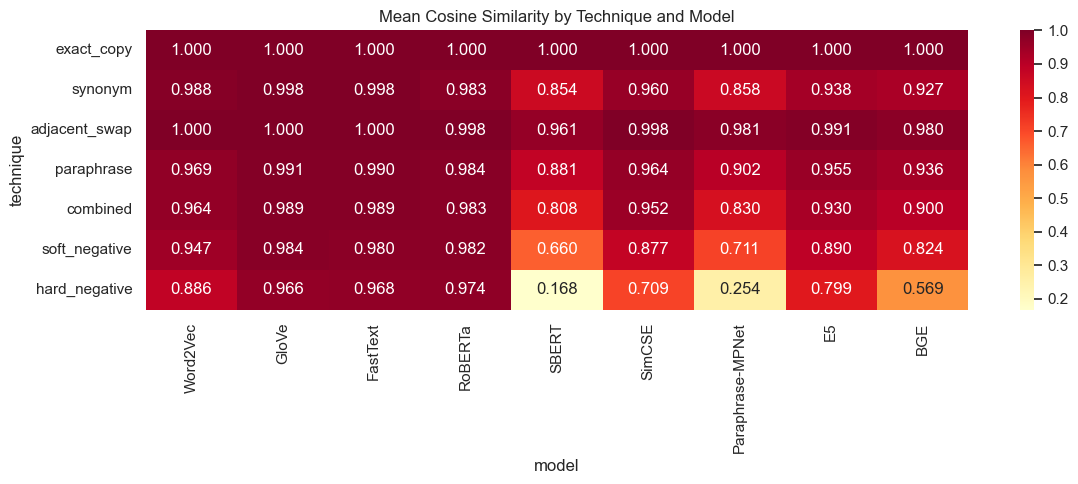

In [23]:
TECHNIQUE_ORDER = ['exact_copy', 'synonym', 'adjacent_swap', 'paraphrase', 'combined', 'soft_negative', 'hard_negative']
MODEL_ORDER = ['Word2Vec', 'GloVe', 'FastText', 'RoBERTa', 'SBERT', 'SimCSE', 'Paraphrase-MPNet', 'E5', 'BGE']

cosine_df = results_df[results_df['metric'] == 'cosine']
pivot = cosine_df.pivot_table(values='similarity', index='technique', columns='model', aggfunc='mean')
pivot = pivot.reindex(index=TECHNIQUE_ORDER, columns=MODEL_ORDER)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Mean Cosine Similarity by Technique and Model')
plt.tight_layout()
plt.show()

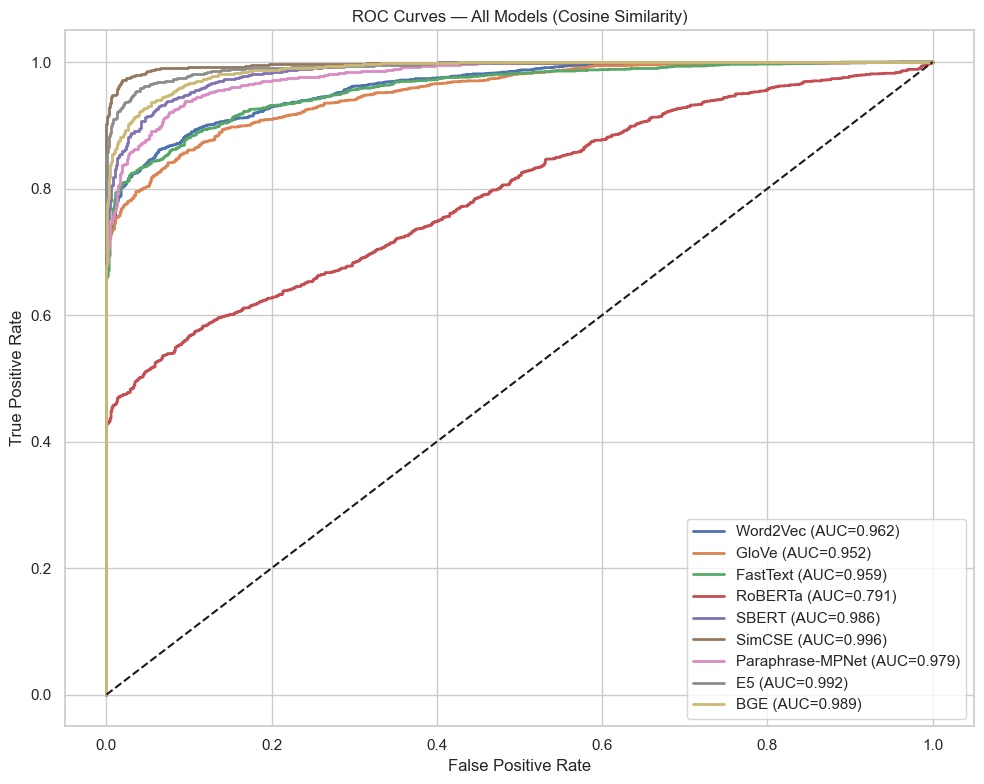

Separation score (plagiarism mean − soft_negative mean):
Word2Vec            0.0377
GloVe               0.0115
FastText            0.0154
RoBERTa             0.0074
SBERT               0.2404
SimCSE              0.0975
Paraphrase-MPNet    0.2030
E5                  0.0724
BGE                 0.1247
dtype: float32

Best model by separation: SBERT (separation = 0.2404)

Best threshold calibration (cosine, maximizing F1):
                  threshold      f1
Word2Vec               0.96  0.9229
GloVe                  0.98  0.9007
FastText               0.98  0.9119
RoBERTa                0.97  0.8402
SBERT                  0.73  0.9581
SimCSE                 0.92  0.9820
Paraphrase-MPNet       0.77  0.9504
E5                     0.91  0.9718
BGE                    0.86  0.9628


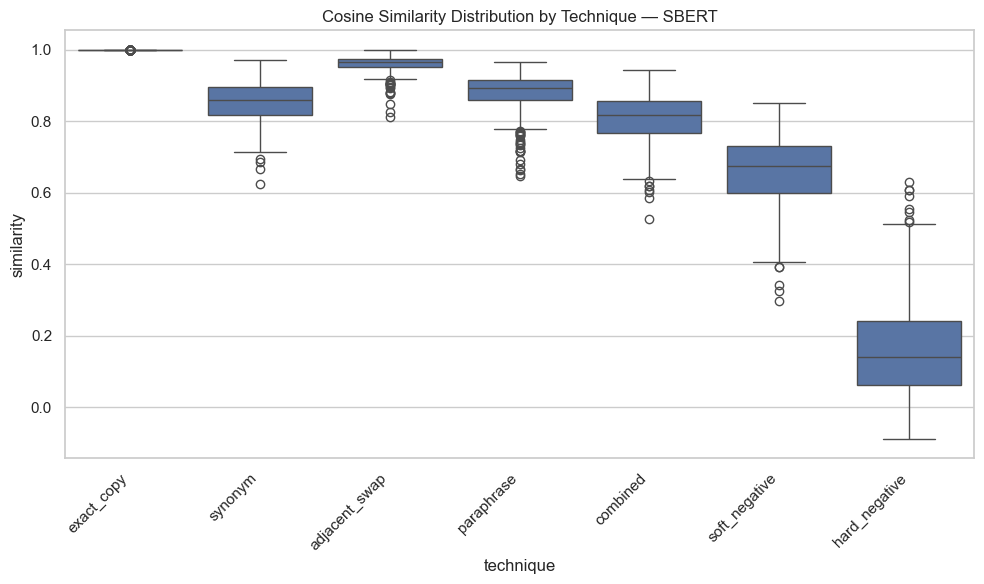

In [24]:
# Separation score, ROC-AUC, best threshold calibration, and score distribution
plt.figure(figsize=(10, 8))
for model_name in MODEL_ORDER:
    subset = cosine_df[cosine_df['model'] == model_name]
    fpr, tpr, _ = roc_curve(subset['is_plagiarism'], subset['similarity'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={auc_scores[model_name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Cosine Similarity)')
plt.legend()
plt.tight_layout()
plt.show()

plagiarism_techs = ['exact_copy', 'synonym', 'adjacent_swap', 'paraphrase', 'combined']
separation_scores = {}
for model_name in MODEL_ORDER:
    subset = cosine_df[cosine_df['model'] == model_name]
    plag_mean = subset[subset['technique'].isin(plagiarism_techs)]['similarity'].mean()
    same_mean = subset[subset['technique'] == 'soft_negative']['similarity'].mean()
    separation_scores[model_name] = plag_mean - same_mean

sep_s = pd.Series(separation_scores).reindex(MODEL_ORDER)
best_model = sep_s.idxmax()
print('Separation score (plagiarism mean − soft_negative mean):')
print(sep_s.round(4))
print(f'\nBest model by separation: {best_model} (separation = {sep_s[best_model]:.4f})')

thresholds = np.arange(0.0, 1.01, 0.01)
optimal = {}
for model_name in MODEL_ORDER:
    subset = cosine_df[cosine_df['model'] == model_name]
    best_f1, best_t = 0, 0
    for t in thresholds:
        preds = (subset['similarity'] >= t).astype(int)
        f1 = f1_score(subset['is_plagiarism'], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    optimal[model_name] = {'threshold': best_t, 'f1': best_f1}

opt_df = pd.DataFrame(optimal).T.reindex(MODEL_ORDER)
print('\nBest threshold calibration (cosine, maximizing F1):')
print(opt_df.round(4))

best_data = cosine_df[cosine_df['model'] == best_model].copy()
best_data['technique'] = pd.Categorical(best_data['technique'], categories=TECHNIQUE_ORDER, ordered=True)
plt.figure(figsize=(10, 6))
sns.boxplot(data=best_data, x='technique', y='similarity', order=TECHNIQUE_ORDER)
plt.title(f'Cosine Similarity Distribution by Technique — {best_model}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Reading The Similarity Metrics

- **SBERT** is best by separation, so it creates the biggest average safety margin against same-assignment negatives.
- **SimCSE** is best by ROC-AUC, so its cosine scores rank plagiarism and non-plagiarism pairs most cleanly overall.
- The calibrated threshold table turns that ranking into an actual detector by choosing the threshold with the best `F1` for each model.

Contextual sentence-pair models dominate, cosine is the natural readout, and the hardest plagiarism variant remains `combined` because it accumulates several distortions at once.

## 7. Linear Probe With A Simple Linear Head

This probe keeps the encoder frozen and trains only one linear classification head on top of concatenated pair embeddings `[u; v]`. The split is grouped by `essay_id`, so one source essay never leaks between train and test.

Linear probe metrics with concatenated pair embeddings (grouped split by essay_id):
                  roc_auc      f1  accuracy
model                                      
Word2Vec           0.5326  0.5549    0.5193
GloVe              0.5949  0.6026    0.5646
FastText           0.5080  0.5370    0.5004
RoBERTa            0.5721  0.5828    0.5498
SBERT              0.4433  0.4744    0.4510
SimCSE             0.4646  0.4895    0.4782
Paraphrase-MPNet   0.4601  0.4725    0.4634
E5                 0.4450  0.4650    0.4658
BGE                0.4369  0.4664    0.4576

Top models by linear-probe ROC-AUC:
          roc_auc      f1  accuracy
model                              
GloVe      0.5949  0.6026    0.5646
RoBERTa    0.5721  0.5828    0.5498
Word2Vec   0.5326  0.5549    0.5193


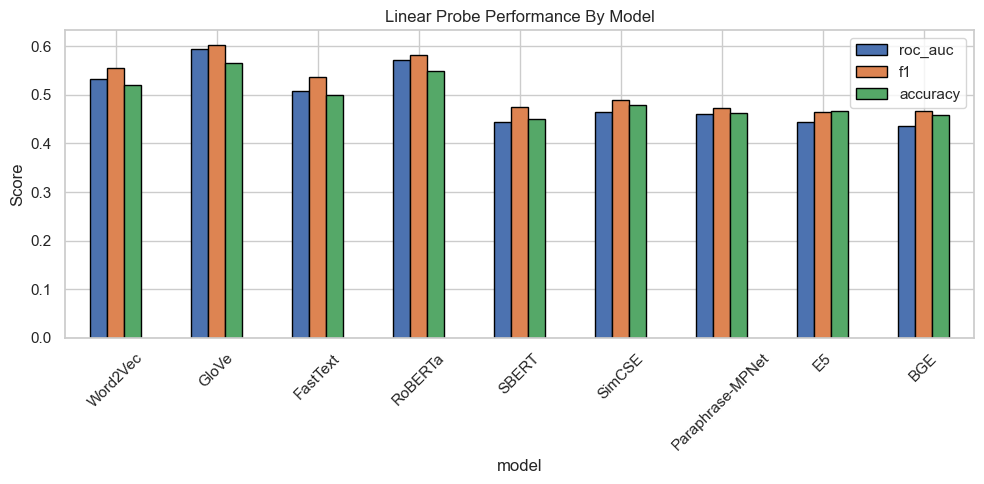

In [25]:
# Linear probe on concatenated pair embeddings
negative_records = []
for group in negative_pair_groups:
    for _ in group['soft_negatives']:
        negative_records.append({'essay_id': group['essay_id'], 'technique': 'soft_negative', 'is_plagiarism': 0})
    negative_records.append({'essay_id': group['essay_id'], 'technique': 'hard_negative', 'is_plagiarism': 0})

pair_meta = pd.concat([
    df[['essay_id', 'technique', 'is_plagiarism']].copy(),
    pd.DataFrame(negative_records)
], ignore_index=True)

y_probe = pair_meta['is_plagiarism'].to_numpy()
groups_probe = pair_meta['essay_id'].to_numpy()
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, test_idx = next(splitter.split(np.zeros(len(pair_meta)), y_probe, groups_probe))

linear_probe_results = []
for model_name in MODEL_ORDER:
    orig_all = np.vstack([
        embeddings[model_name]['original'],
        soft_neg_embeddings[model_name]['original'],
        hard_neg_embeddings[model_name]['original']
    ])
    comp_all = np.vstack([
        embeddings[model_name]['compared'],
        soft_neg_embeddings[model_name]['compared'],
        hard_neg_embeddings[model_name]['compared']
    ])
    X_probe = np.hstack([orig_all, comp_all])

    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
    probe.fit(X_probe[train_idx], y_probe[train_idx])
    prob = probe.predict_proba(X_probe[test_idx])[:, 1]
    pred = (prob >= 0.5).astype(int)

    linear_probe_results.append({
        'model': model_name,
        'roc_auc': roc_auc_score(y_probe[test_idx], prob),
        'f1': f1_score(y_probe[test_idx], pred),
        'accuracy': accuracy_score(y_probe[test_idx], pred)
    })

linear_probe_df = pd.DataFrame(linear_probe_results).set_index('model').reindex(MODEL_ORDER)
linear_probe_sorted = linear_probe_df.sort_values(['roc_auc', 'f1'], ascending=False)
linear_probe_best_model = linear_probe_sorted.index[0]

print('Linear probe metrics with concatenated pair embeddings (grouped split by essay_id):')
print(linear_probe_df.round(4))
print('\nTop models by linear-probe ROC-AUC:')
print(linear_probe_sorted[['roc_auc', 'f1', 'accuracy']].head(3).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
linear_probe_df[['roc_auc', 'f1', 'accuracy']].plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Linear Probe Performance By Model')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Reading The Linear Probe

This experiment is intentionally simple, but it is not the natural readout for sentence-similarity models. That is why it produces the counterintuitive ordering where `GloVe` and `RoBERTa` look stronger than `SBERT`, `SimCSE`, `E5`, and `BGE`. Concatenation + linear head can overemphasize lexical or prompt-correlated cues instead of the cleaner similarity geometry.

## 8. Holdout Cosine Threshold Baseline

This baseline is on the same grouped holdout. The encoder stays frozen, we read each pair through cosine similarity, and for each model we calibrate one threshold on the train split by maximizing `F1`.

Holdout cosine-threshold results:
                  threshold  train_f1  test_roc_auc  test_f1  test_accuracy
model                                                                      
Word2Vec             0.9612    0.8594        0.9307   0.8561         0.8329
GloVe                0.9897    0.8465        0.9197   0.8452         0.8296
FastText             0.9905    0.8592        0.9403   0.8638         0.8568
RoBERTa              0.9760    0.7422        0.7284   0.7228         0.6099
SBERT                0.7769    0.9086        0.9702   0.9141         0.9045
SimCSE               0.9347    0.9629        0.9891   0.9613         0.9572
Paraphrase-MPNet     0.8202    0.8940        0.9585   0.8920         0.8840
E5                   0.9178    0.9378        0.9819   0.9441         0.9383
BGE                  0.8837    0.9197        0.9765   0.9279         0.9202

Top models by holdout cosine ROC-AUC:
        threshold  test_roc_auc  test_f1  test_accuracy
model                              

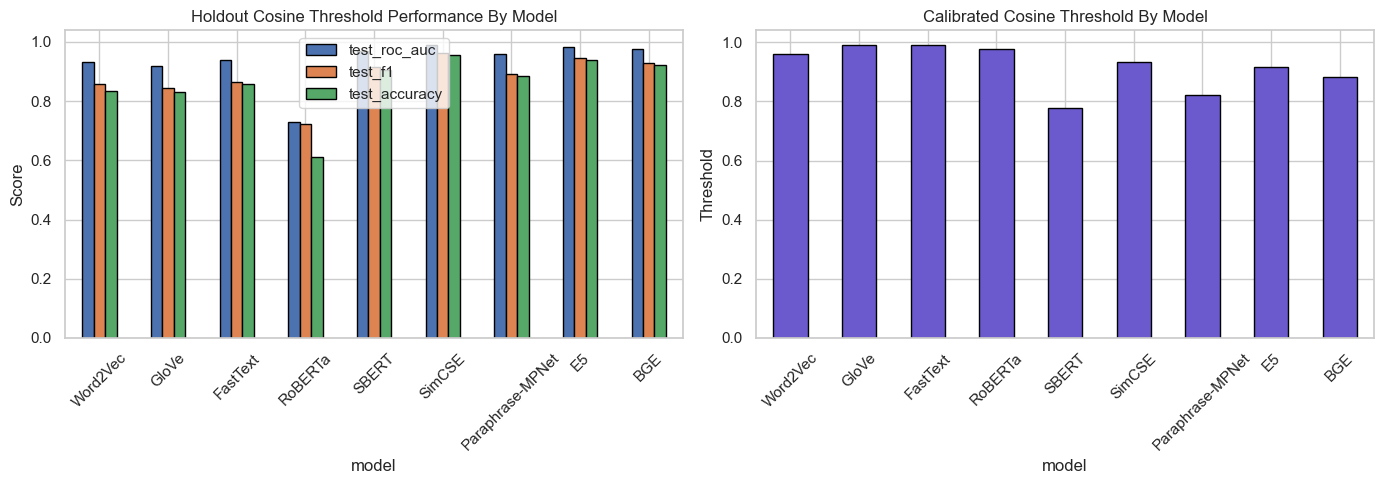

In [26]:
# Holdout cosine-threshold baseline with train-only threshold calibration
def calibrate_cosine_threshold(scores, y_true, train_idx, test_idx):
    threshold_grid = np.linspace(scores[train_idx].min(), scores[train_idx].max(), 401)
    best_threshold = float(threshold_grid[0])
    best_train_f1 = -1.0
    for threshold in threshold_grid:
        pred_train = (scores[train_idx] >= threshold).astype(int)
        train_f1 = f1_score(y_true[train_idx], pred_train, zero_division=0)
        if train_f1 > best_train_f1:
            best_train_f1 = train_f1
            best_threshold = float(threshold)
    pred_test = (scores[test_idx] >= best_threshold).astype(int)
    return {
        'threshold': best_threshold,
        'train_f1': best_train_f1,
        'test_roc_auc': roc_auc_score(y_true[test_idx], scores[test_idx]),
        'test_f1': f1_score(y_true[test_idx], pred_test, zero_division=0),
        'test_accuracy': accuracy_score(y_true[test_idx], pred_test)
    }

threshold_results = []
for model_name in MODEL_ORDER:
    orig_all = np.vstack([
        embeddings[model_name]['original'],
        soft_neg_embeddings[model_name]['original'],
        hard_neg_embeddings[model_name]['original']
    ])
    comp_all = np.vstack([
        embeddings[model_name]['compared'],
        soft_neg_embeddings[model_name]['compared'],
        hard_neg_embeddings[model_name]['compared']
    ])
    cosine_scores = cosine_sim(orig_all, comp_all)
    stats = calibrate_cosine_threshold(cosine_scores, y_probe, train_idx, test_idx)
    threshold_results.append({'model': model_name, **stats})

threshold_baseline_df = pd.DataFrame(threshold_results).set_index('model').reindex(MODEL_ORDER)
threshold_baseline_sorted = threshold_baseline_df.sort_values(['test_roc_auc', 'test_f1'], ascending=False)
best_threshold_model = threshold_baseline_sorted.index[0]

print('Holdout cosine-threshold results:')
print(threshold_baseline_df.round(4))
print('\nTop models by holdout cosine ROC-AUC:')
print(threshold_baseline_sorted[['threshold', 'test_roc_auc', 'test_f1', 'test_accuracy']].head(3).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
threshold_baseline_df[['test_roc_auc', 'test_f1', 'test_accuracy']].plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Holdout Cosine Threshold Performance By Model')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

threshold_baseline_df['threshold'].plot(kind='bar', ax=axes[1], color='slateblue', edgecolor='black')
axes[1].set_title('Calibrated Cosine Threshold By Model')
axes[1].set_ylabel('Threshold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Reading The Holdout Cosine Baseline

The ranking flips back to the semantically sensible order: `SimCSE` is best, followed by `E5`, `BGE`, and `SBERT`. These models were trained so that semantic neighbors are close in cosine space, so cosine + calibrated threshold exposes their strengths much better than raw concatenation.

## 9. Conclusions

If we read the embeddings through **pairwise cosine similarity**, the strongest models are the ones that were explicitly trained for semantic pairing: `SimCSE`, then `E5`, then `BGE`, then `SBERT`. That order matches the training objectives. These models are designed so that semantically equivalent texts cluster together and merely topically similar texts stay farther apart.

`soft_negative` pairs come from the **same assignment group**, so the real challenge is to separate **same topic** from **same meaning**.

The plagiarism techniques follow the same logic. `exact_copy` and `adjacent_swap` stay easiest because the text barely moves away from the source. `synonym` and `paraphrase` are harder but still strongly detectable when the model captures semantics well. `combined` is hardest because several distortions accumulate at once.

The linear probe isn't useful. Pairwise cosine similarity with train-only threshold calibration is the right readout for this notebook, and `SimCSE` is the strongest candidate among the tested models.

After all, semantic sentence-embedding models can be usable for plagiarism-like detection.